In [37]:
print("hello world")

hello world


In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path
import os

In [39]:
BASE_DIR = Path().resolve().parent  # adjust if needed
DATA_PATH = BASE_DIR / "data_v2" / "train"

IMG_PATH = DATA_PATH / "img"
MSK_PATH = DATA_PATH / "msk"

In [40]:
img_files = sorted(os.listdir(IMG_PATH))
msk_files = sorted(os.listdir(MSK_PATH))

print("Total images:", len(img_files))
print("Total masks:", len(msk_files))

Total images: 622
Total masks: 622


In [41]:
idx = random.randint(0, len(img_files) - 1)

img_file = img_files[idx]
msk_file = img_file.replace("img", "msk")

print("Image:", img_file)
print("Mask :", msk_file)

Image: train_img_000177.png
Mask : train_msk_000177.png


In [42]:
img = cv2.imread(str(IMG_PATH / img_file), cv2.IMREAD_GRAYSCALE)
msk = cv2.imread(str(MSK_PATH / msk_file), cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Mask shape :", msk.shape)
print("Mask unique values:", np.unique(msk))

Image shape: (256, 256)
Mask shape : (256, 256)
Mask unique values: [  0  60 120 180]


In [43]:
msk_norm = msk.astype(np.float32)

if msk_norm.max() > 0:
    msk_norm = msk_norm / msk_norm.max()

In [44]:
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

mask_color = np.zeros_like(img_color)
mask_color[:, :, 0] = (msk_norm * 255).astype(np.uint8)  # Red channel

overlay = cv2.addWeighted(img_color, 0.7, mask_color, 0.3, 0)

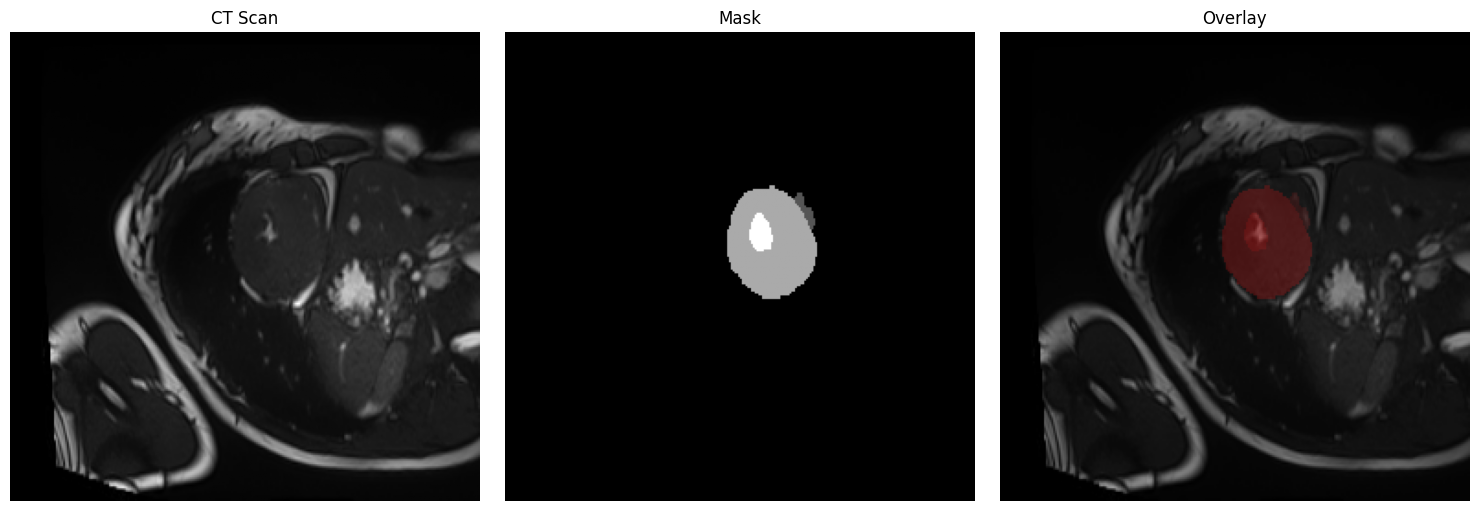

In [45]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("CT Scan")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(msk, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()